In [3]:
import scipy.io as sio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import CCA

def load_mouse_session(path):
    mat = sio.loadmat(path, squeeze_me=True, struct_as_record=False)

    # Column names
    colnames = [str(x) for x in np.ravel(mat["licks_mat_columnName"])]
    licks = pd.DataFrame(mat["licks_mat"], columns=colnames)

    face = np.asarray(mat["FacePCs"])
    m2 = np.asarray(mat["Neurons_M2"]) if "Neurons_M2" in mat else None
    ofc = np.asarray(mat["Neurons_OFC"]) if "Neurons_OFC" in mat else None
    olf = np.asarray(mat["Neurons_OLF"]) if "Neurons_OLF" in mat else None

    return {
        "licks": licks,
        "face": face,
        "m2": m2,
        "ofc": ofc,
        "olf": olf,
    }

def summarize_session(data):
    summary = {
        "n_licks": len(data["licks"]),
        "n_face_pcs": data["face"].shape[1],
        "n_m2": 0 if data["m2"] is None else data["m2"].shape[1],
        "n_ofc": 0 if data["ofc"] is None else data["ofc"].shape[1],
        "n_olf": 0 if data["olf"] is None else data["olf"].shape[1],
    }
    return pd.Series(summary)

def zscore_cols(X):
    if X is None:
        return None
    X = np.asarray(X, dtype=float)
    mu = X.mean(axis=0, keepdims=True)
    sd = X.std(axis=0, keepdims=True)
    sd[sd == 0] = 1.0
    return (X - mu) / sd

def plot_scree(X, title):
    Xz = zscore_cols(X)
    pca = PCA()
    pca.fit(Xz)
    plt.figure(figsize=(6,4))
    plt.plot(np.cumsum(pca.explained_variance_ratio_))
    plt.xlabel("Number of components")
    plt.ylabel("Cumulative explained variance")
    plt.title(title)
    plt.show()

def plot_embedding(X, color, title):
    Xz = zscore_cols(X)
    pca = PCA(n_components=2)
    emb = pca.fit_transform(Xz)
    plt.figure(figsize=(6,5))
    sc = plt.scatter(emb[:,0], emb[:,1], c=color, s=8, alpha=0.7)
    plt.colorbar(sc)
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()

def correlation_with_behavior(X, y, top_k=20):
    X = np.asarray(X)
    out = []
    for j in range(min(X.shape[1], top_k)):
        r = np.corrcoef(X[:, j], y)[0, 1]
        out.append((j, r))
    return pd.DataFrame(out, columns=["feature", "corr"]).sort_values("corr", key=np.abs, ascending=False)

def cca_score(X, Y, n_components=3):
    Xz = zscore_cols(X)
    Yz = zscore_cols(Y)
    cca = CCA(n_components=n_components)
    Xc, Yc = cca.fit_transform(Xz, Yz)
    cors = [np.corrcoef(Xc[:,i], Yc[:,i])[0,1] for i in range(n_components)]
    return cors

folder="/home/maria/Science/data/mouse_face_data/29117360/"

data = load_mouse_session(folder+"Mouse_Ephys_1.mat")
print(summarize_session(data))
print(data["licks"].head())
print(data["licks"].columns.tolist())

n_licks       1851
n_face_pcs     500
n_m2            73
n_ofc           72
n_olf           66
dtype: int64
   time all licks  first lick  last lick  reward  last reward  trial number  \
0             NaN         0.0        0.0     0.0          0.0           0.0   
1             NaN         0.0        0.0     0.0          0.0           0.0   
2             NaN         0.0        0.0     0.0          0.0           0.0   
3             NaN         0.0        0.0     0.0          0.0           0.0   
4             NaN         0.0        0.0     0.0          0.0           0.0   

   consecutive failures  
0                   NaN  
1                   NaN  
2                   NaN  
3                   NaN  
4                   NaN  
['time all licks', 'first lick', 'last lick', 'reward', 'last reward', 'trial number', 'consecutive failures']


In [4]:
# How many NaNs per column?
print(data["licks"].isna().sum())

# How many rows have any NaN?
print((data["licks"].isna().any(axis=1)).sum())

# Show first rows that are actually complete
print(data["licks"][~data["licks"].isna().any(axis=1)].head())

# Show rows where trial number becomes nonzero
print(data["licks"][data["licks"]["trial number"] > 0].head(10))

time all licks           13
first lick                0
last lick                 0
reward                    0
last reward               0
trial number              0
consecutive failures    100
dtype: int64
100
    time all licks  first lick  last lick  reward  last reward  trial number  \
13       28.939108         1.0        0.0     1.0          0.0           1.0   
14       29.056333         0.0        0.0     1.0          0.0           1.0   
15       29.173558         0.0        0.0     1.0          0.0           1.0   
16       29.289781         0.0        0.0     0.0          0.0           1.0   
17       29.407006         0.0        0.0     1.0          0.0           1.0   

    consecutive failures  
13                   0.0  
14                   0.0  
15                   0.0  
16                   1.0  
17                   0.0  
    time all licks  first lick  last lick  reward  last reward  trial number  \
13       28.939108         1.0        0.0     1.0          0.0  

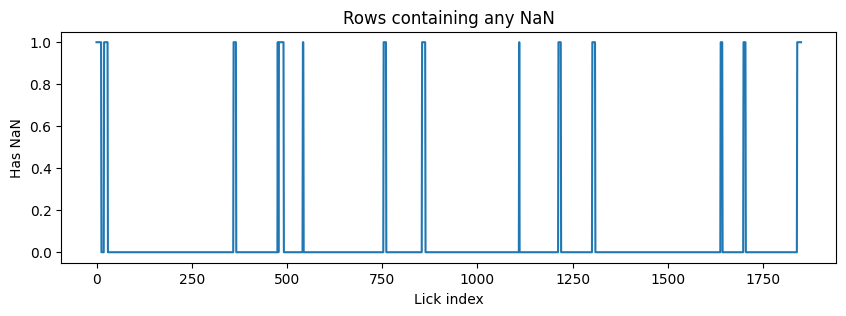

In [5]:
plt.figure(figsize=(10, 3))
plt.plot(data["licks"].isna().any(axis=1).astype(int))
plt.title("Rows containing any NaN")
plt.xlabel("Lick index")
plt.ylabel("Has NaN")
plt.show()

In [9]:
mask = (
    data["licks"]["trial number"].notna() &
    (data["licks"]["trial number"] > 0) &
    data["licks"]["time all licks"].notna()
)

licks_clean = data["licks"].loc[mask].copy()
face_clean = data["face"][mask.values]
m2_clean = data["m2"][mask.values]
ofc_clean = data["ofc"][mask.values]
olf_clean = data["olf"][mask.values]

licks_clean.groupby("trial number").agg({
    "first lick": "sum",
    "last lick": "sum",
    "reward": "sum",
    "consecutive failures": "max"
}).head(500)

,first lick,last lick,reward,consecutive failures
trial number,,,,
1.0,1.0,1.0,6.0,1.0
2.0,1.0,1.0,8.0,4.0
3.0,1.0,1.0,7.0,8.0
4.0,1.0,1.0,1.0,10.0
5.0,1.0,1.0,4.0,6.0
...,...,...,...,...
184.0,1.0,1.0,1.0,3.0
185.0,1.0,1.0,12.0,5.0
186.0,1.0,1.0,15.0,7.0


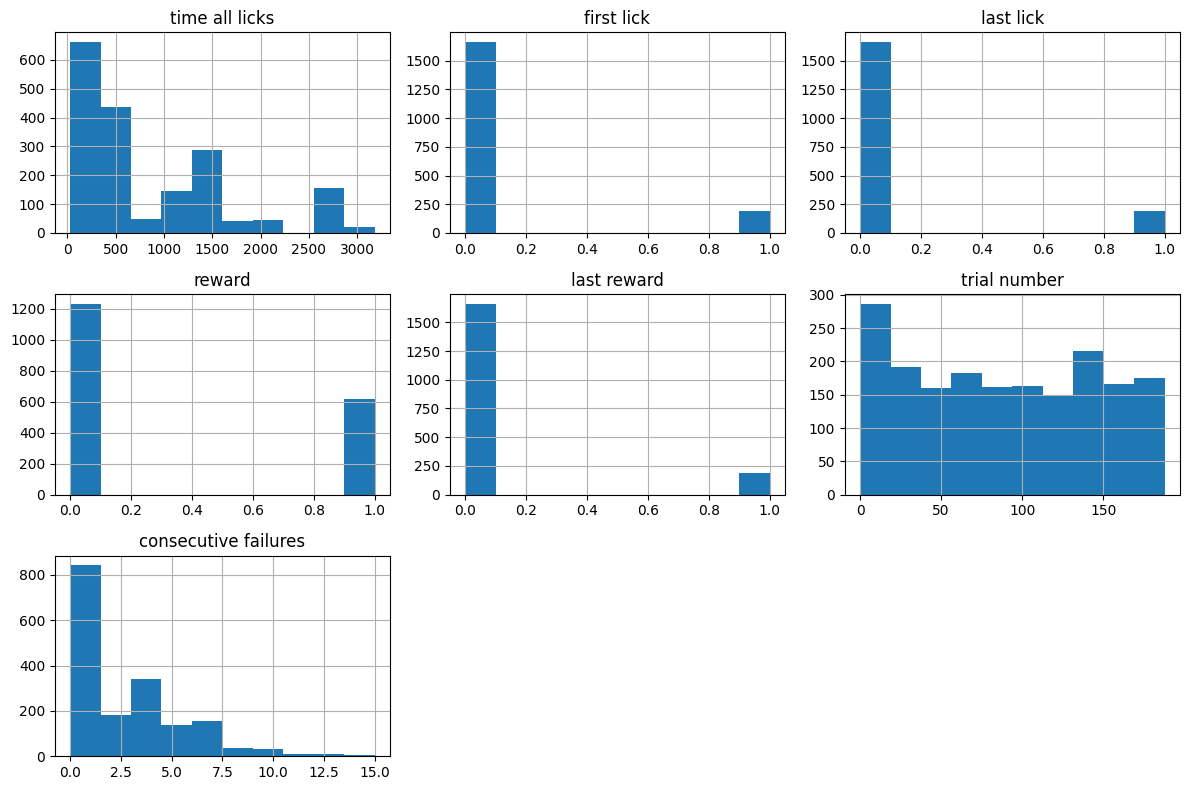

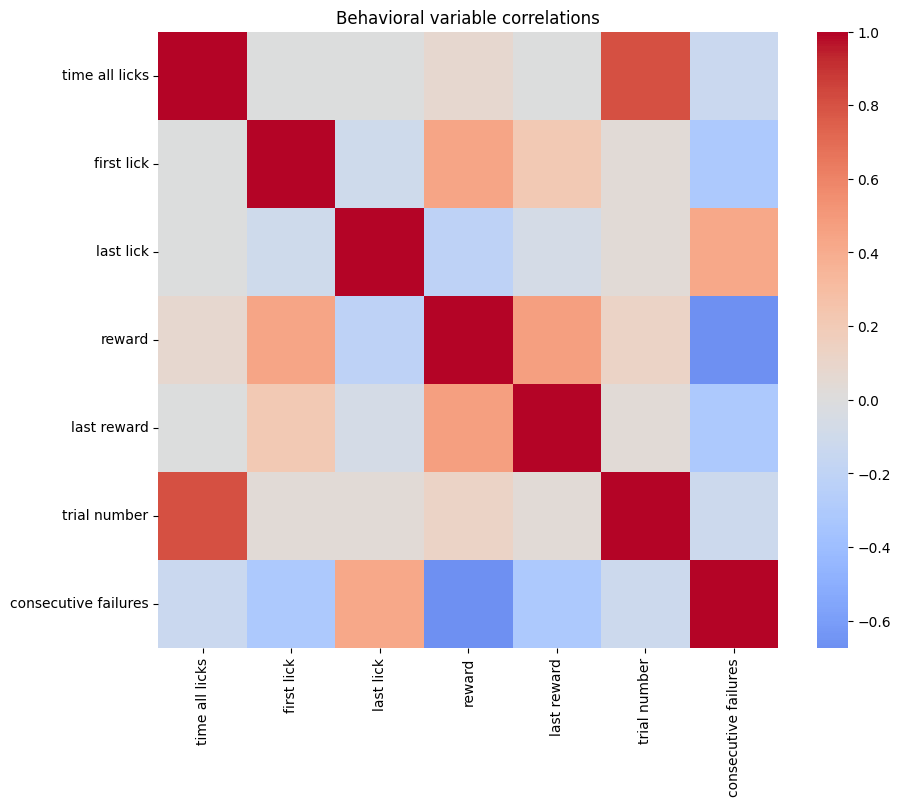

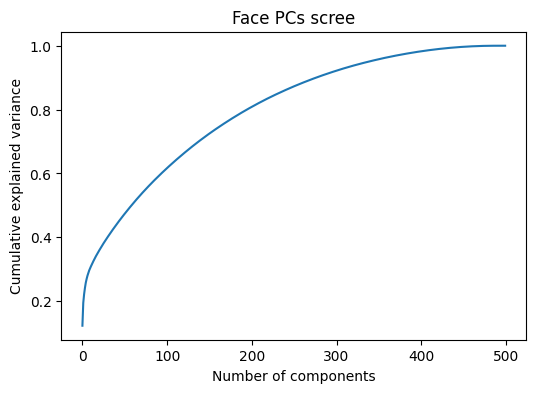

In [10]:
# Behavioral distributions
data["licks"].hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

# Behavioral correlations
plt.figure(figsize=(10, 8))
sns.heatmap(data["licks"].corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Behavioral variable correlations")
plt.show()

# Face structure
plot_scree(data["face"], "Face PCs scree")

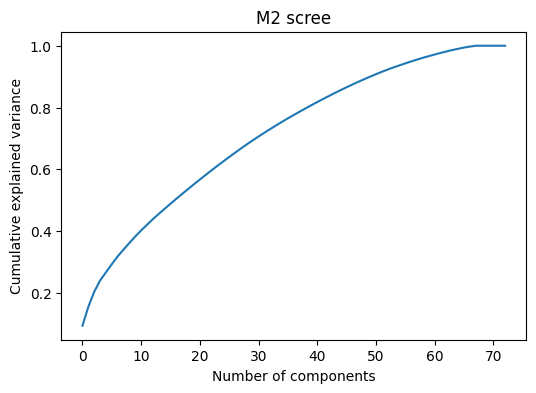

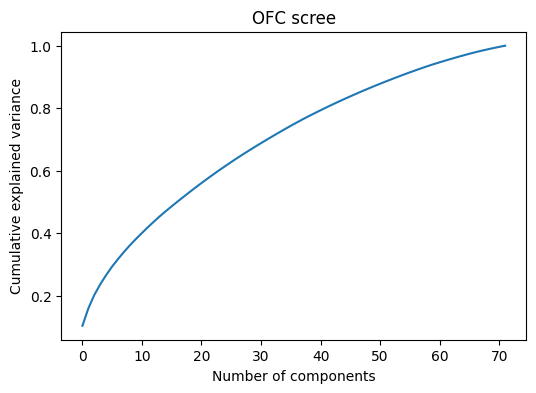

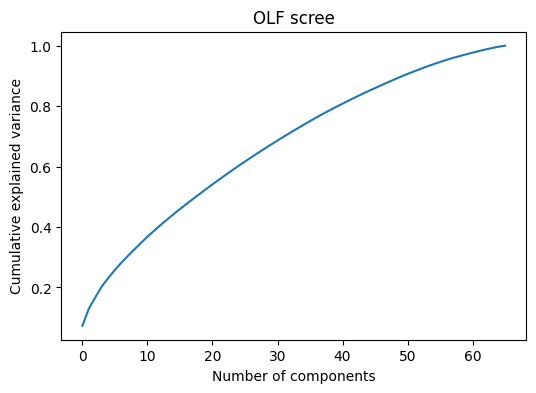

In [13]:
if data["m2"] is not None:
    plot_scree(data["m2"], "M2 scree")
if data["ofc"] is not None:
    plot_scree(data["ofc"], "OFC scree")
if data["olf"] is not None:
    plot_scree(data["olf"], "OLF scree")

In [14]:
if data["m2"] is not None:
    print("CCA Face-M2:", cca_score(data["face"][:, :30], data["m2"], n_components=3))
if data["ofc"] is not None:
    print("CCA Face-OFC:", cca_score(data["face"][:, :30], data["ofc"], n_components=3))
if data["olf"] is not None:
    print("CCA Face-OLF:", cca_score(data["face"][:, :30], data["olf"], n_components=3))

CCA Face-M2: [np.float64(0.8902788953131574), np.float64(0.836311792848747), np.float64(0.716138629295829)]
CCA Face-OFC: [np.float64(0.8012657954416463), np.float64(0.7009550515671551), np.float64(0.6323520222225059)]
CCA Face-OLF: [np.float64(0.7099439788614146), np.float64(0.6884899759892751), np.float64(0.6104548803542844)]
